In [1]:
import pandas as pd
import numpy as np
import glob
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from decimal import Decimal, getcontext

Dzielenie cięciw ze względu na metodę.

c:\Users\Jan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 348s 2ms/step - accuracy: 0.5821 - loss: 0.8465 - val_accuracy: 0.5869 - val_loss: 0.8349
Epoch 2/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 334s 2ms/step - accuracy: 0.5868 - loss: 0.8360 - val_accuracy: 0.5882 - val_loss: 0.8322
Epoch 3/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 348s 2ms/step - accuracy: 0.5873 - loss: 0.8350 - val_accuracy: 0.5866 - val_loss: 0.8338
Epoch 4/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 324s 1ms/step - accuracy: 0.5878 - loss: 0.8344 - val_accuracy: 0.5878 - val_loss: 0.8330
Epoch 5/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 328s 2ms/step - accuracy: 0.5880 - loss: 0.8339 - val_accuracy: 0.5874 - val_loss: 0.8326
Epoch 6/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 331s 2ms/step - accuracy: 0.5885 - loss: 0.8334 - val_accuracy: 0.5892 - val_loss: 0.8313
Epoch 7/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 334s 2ms/step - accuracy: 0.5884 - loss: 0.8336 - val_accuracy: 0.5887 - val_loss: 0.8307
Epoch 8/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 34

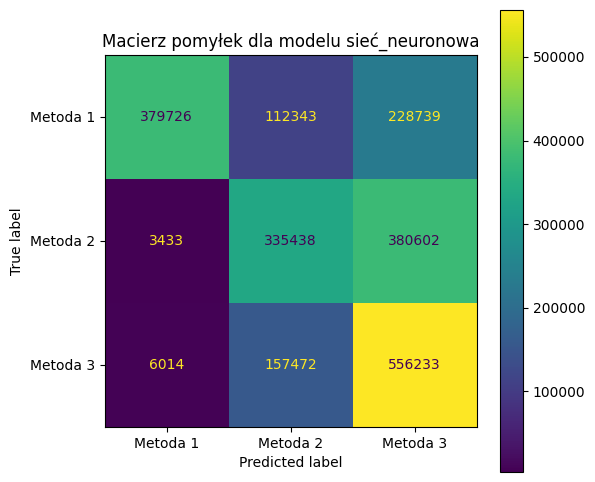

Model i scaler zapisane.


In [2]:
method_1_files=glob.glob("../dane/metoda_1_*.csv")
method_2_files=glob.glob("../dane/metoda_2_*.csv")
method_3_files=glob.glob("../dane/metoda_3_*.csv")

def load_and_process(filepaths,method_label):
    dfs=[]
    for path in filepaths:
        df=pd.read_csv(path)
        df['distance_from_center']=np.sqrt(df['center_x']**2+df['center_y']**2)
        df['method']=method_label
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

df1=load_and_process(method_1_files,method_label=0)
df2=load_and_process(method_2_files,method_label=1)
df3=load_and_process(method_3_files,method_label=2)
data=pd.concat([df1,df2,df3],ignore_index=True)

features=['x1','y1','x2','y2','length','center_x','center_y','distance_from_center']
X=data[features]
y=data['method']

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
y_cat=tf.keras.utils.to_categorical(y,num_classes=3)

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y_cat,test_size=0.2,random_state=42)

model=Sequential([
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dropout(0.2),
    Dense(3,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history=model.fit(X_train,y_train, epochs=20,batch_size=32,validation_split=0.2,verbose=1)

loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print(f'Dokładność na danych testowych: {accuracy:.4f}')

y_pred_probs=model.predict(X_test)
y_pred=np.argmax(y_pred_probs,axis=1)
y_true=np.argmax(y_test,axis=1)

cm=confusion_matrix(y_true,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Metoda 1','Metoda 2','Metoda 3'])
fig,ax=plt.subplots(figsize=(6,6))
disp.plot(ax=ax)
plt.title('Macierz pomyłek dla modelu sieć_neuronowa')
plt.savefig('macierz_pomyłek_dla_sieć_neuronowa.png',dpi=300)
plt.show()
model.save("model_cieć_neuronowa.h5")
joblib.dump(scaler, "scaler_do_model_cieć_neuronowa.pkl")
print("Model i scaler zapisane.")

Dzielenie cięciw ze względu na metodę i długość.

c:\Users\Jan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 389s 2ms/step - accuracy: 0.5774 - loss: 0.8715 - val_accuracy: 0.5879 - val_loss: 0.8389
Epoch 2/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 412s 2ms/step - accuracy: 0.5850 - loss: 0.8482 - val_accuracy: 0.5870 - val_loss: 0.8404
Epoch 3/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 409s 2ms/step - accuracy: 0.5856 - loss: 0.8462 - val_accuracy: 0.5850 - val_loss: 0.8397
Epoch 4/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 428s 2ms/step - accuracy: 0.5861 - loss: 0.8454 - val_accuracy: 0.5866 - val_loss: 0.8399
Epoch 5/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 397s 2ms/step - accuracy: 0.5866 - loss: 0.8447 - val_accuracy: 0.5882 - val_loss: 0.8399
Epoch 6/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 395s 2ms/step - accuracy: 0.5863 - loss: 0.8453 - val_accuracy: 0.5874 - val_loss: 0.8355
Epoch 7/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 378s 2ms/step - accuracy: 0.5870 - loss: 0.8442 - val_accuracy: 0.5870 - val_loss: 0.8390
Epoch 8/20
216000/216000 ━━━━━━━━━━━━━━━━━━━━ 38

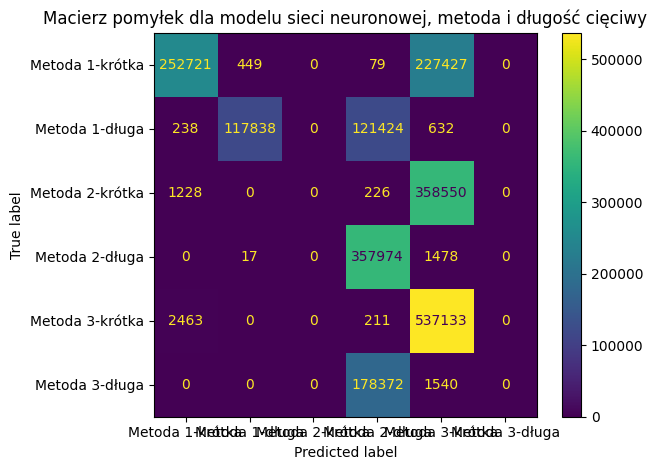

Model i scaler zapisane.


In [3]:
method_1_files=glob.glob("../dane/metoda_1_*.csv")
method_2_files=glob.glob("../dane/metoda_2_*.csv")
method_3_files=glob.glob("../dane/metoda_3_*.csv")

def load_and_process(filepaths,method_label):
    dfs=[]
    for path in filepaths:
        df=pd.read_csv(path)
        df['distance_from_center']=np.sqrt(df['center_x']**2+df['center_y']**2)
        df['method']=method_label
        df['class']=(method_label-1)*2+df['is_longer']+1
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

df1=load_and_process(method_1_files,method_label=1)
df2=load_and_process(method_2_files,method_label=2)
df3=load_and_process(method_3_files,method_label=3)
data=pd.concat([df1,df2,df3],ignore_index=True)

features=['x1','y1','x2','y2','length','center_x','center_y','distance_from_center']
X=data[features]
y=data['class']

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
y_cat=tf.keras.utils.to_categorical(y-1,num_classes=6)

X_train,X_test,y_train,y_test=train_test_split(X_scaled,y_cat,test_size=0.2,random_state=42)

model=Sequential([
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dropout(0.2),
	Dense(16,activation='relu'),
	Dropout(0.2),
    Dense(6,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history=model.fit(X_train,y_train, epochs=20,batch_size=32,validation_split=0.2,verbose=1)

loss,accuracy=model.evaluate(X_test,y_test,verbose=0)
print(f'Dokładność na danych testowych: {accuracy:.4f}')

y_pred_probs=model.predict(X_test)
y_pred=np.argmax(y_pred_probs,axis=1)
y_true=np.argmax(y_test,axis=1)

labels=[0,1,2,3,4,5]
label_names=['Metoda 1-krótka','Metoda 1-długa','Metoda 2-krótka','Metoda 2-długa','Metoda 3-krótka','Metoda 3-długa']

cm=confusion_matrix(y_true,y_pred,labels=labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_names)
disp.plot()
plt.title('Macierz pomyłek dla modelu sieci neuronowej, metoda i długość cięciwy')
plt.tight_layout()
plt.savefig('macierz_pomyłek_dla_sieci_neuronowej_metoda_i_długość_cięciwy.png',dpi=300)
plt.show()
model.save("model_cieć_neuronowa_metoda_i_długość_cięciwy.h5")
joblib.dump(scaler, "scaler_do_model_cieć_neuronowa_metoda_i_długość_cięciwy.pkl")
print("Model i scaler zapisane.")

Dzielenie cięciw ze względu na metodę i długość, z wykorzystaiem neiwidocznych końcówek

In [ ]:
method_1_files=glob.glob("../metoda_1_*.csv")
method_2_files=glob.glob("../metoda_2_*.csv")
method_3_files=glob.glob("../metoda_3_*.csv")

def load_and_process(filepaths,method_label):
    dfs=[]
    for path in filepaths:
        df=pd.read_csv(path,dtype=str)
        
        numeric_cols=['x1','y1','x2','y2','length']
        df=split_float64_and_tail(df,numeric_cols)
        df['distance_from_center']=np.sqrt(df['center_x']**2+df['center_y']**2)
        df['is_longer']=df['is_longer'].astype(int)
        df['method']=method_label
        df['class']=(method_label-1)*2+df['is_longer']+1
        dfs.append(df)
    return pd.concat(dfs,ignore_index=True)

def split_float64_and_tail(df,columns):
    for col in columns:
        floats=[]
        tails=[]
        for v in df[col]:
            dec=Decimal(v)
            f64=Decimal(str(np.float64(v)))
            tail=dec-f64
            floats.append(float(f64))
            tails.append(float(tail))
        
        df[col]=floats
        df[f'{col}_koncowka']=tails
    return df

getcontext().prec=50

df1=load_and_process(method_1_files,method_label=1)
df2=load_and_process(method_2_files,method_label=2)
df3=load_and_process(method_3_files,method_label=3)
data=pd.concat([df1,df2,df3],ignore_index=True)

base_features=['x1','y1','x2','y2','length','center_x','center_y','distance_from_center']
tail_features=[f'{f}_koncowka' for f in ['x1','y1','x2','y2','length','center_x','center_y']]
features=base_features+tail_features
X=data[features].astype(float)
y=data['class']


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

y_train_cat=tf.keras.utils.to_categorical(y_train-1,num_classes=6)
y_test_cat=tf.keras.utils.to_categorical(y_test-1,num_classes=6)

model=Sequential([
    Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dropout(0.2),
	Dense(16,activation='relu'),
	Dropout(0.2),
	Dense(8,activation='relu'),
	Dropout(0.2),
    Dense(6,activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history=model.fit(X_train,y_train_cat, epochs=20,batch_size=32,validation_split=0.2,verbose=1)

loss,accuracy=model.evaluate(X_test,y_test_cat,verbose=0)
print(f'Dokładność na danych testowych: {accuracy:.4f}')
# Zapis dokładności do pliku
with open("dokladnosc_siec_neuronowa.txt", "w", encoding="utf-8") as f:
    f.write(f'Dokładność na danych testowych: {accuracy:.4f}\n')

y_pred_probs=model.predict(X_test)
y_pred=np.argmax(y_pred_probs,axis=1)
y_true=np.argmax(y_test_cat,axis=1)

labels=[0,1,2,3,4,5]
label_names=['Metoda 1-krótka','Metoda 1-długa','Metoda 2-krótka','Metoda 2-długa','Metoda 3-krótka','Metoda 3-długa']

cm=confusion_matrix(y_true,y_pred,labels=labels)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_names)
disp.plot()
plt.title('Macierz pomyłek dla modelu sieci neuronowej, metoda i długość cięciwy z użyciem końcówek')
plt.tight_layout()
plt.savefig('macierz_pomyłek_dla_sieci_neuronowej_metoda_i_długość_cięciwy_z_użyciem_końcówek.png',dpi=300)
plt.show()
model.save("model_cieć_neuronowa_metoda_i_długość_cięciwy_z_użyciem_końcówek.h5")
joblib.dump(scaler, "scaler_do_model_cieć_neuronowa_metoda_i_długość_cięciwy_z_użyciem_końcówek.pkl")
print("Model i scaler zapisane.")